In [1]:
# scikit-learn 의 캘리포니아 주택 가격에 대해 분석, 시각화, 전처리, 머신러닝, 튜닝까지 소스 만들어줘.

1. 데이터 로드

[컬럼 설명]
  MedInc       : 중위 소득 (만 달러)
  HouseAge     : 주택 연령 (년)
  AveRooms     : 평균 방 수
  AveBedrms    : 평균 침실 수
  Population   : 블록 인구 수
  AveOccup     : 평균 거주자 수
  Latitude     : 위도
  Longitude    : 경도
  Price        : 주택 가격 (십만 달러) ← 타겟

데이터 shape : (20640, 9)

2. 탐색적 데이터 분석 (EDA)

[기초 통계량]
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup   Latitude  Longitude      Price
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000  20640.000  20640.000  20640.000
mean       3.871     28.639      5.429      1.097    1425.477      3.071     35.632   -119.570      2.069
std        1.900     12.586      2.474      0.474    1132.462     10.386      2.136      2.004      1.154
min        0.500      1.000      0.846      0.333       3.000      0.692     32.540   -124.350      0.150
25%        2.563     18.000      4.441      1.006     787.000      2.430     33.930   -121.800      1.196
50%        3.535     29.000      5.229      1.049    1166

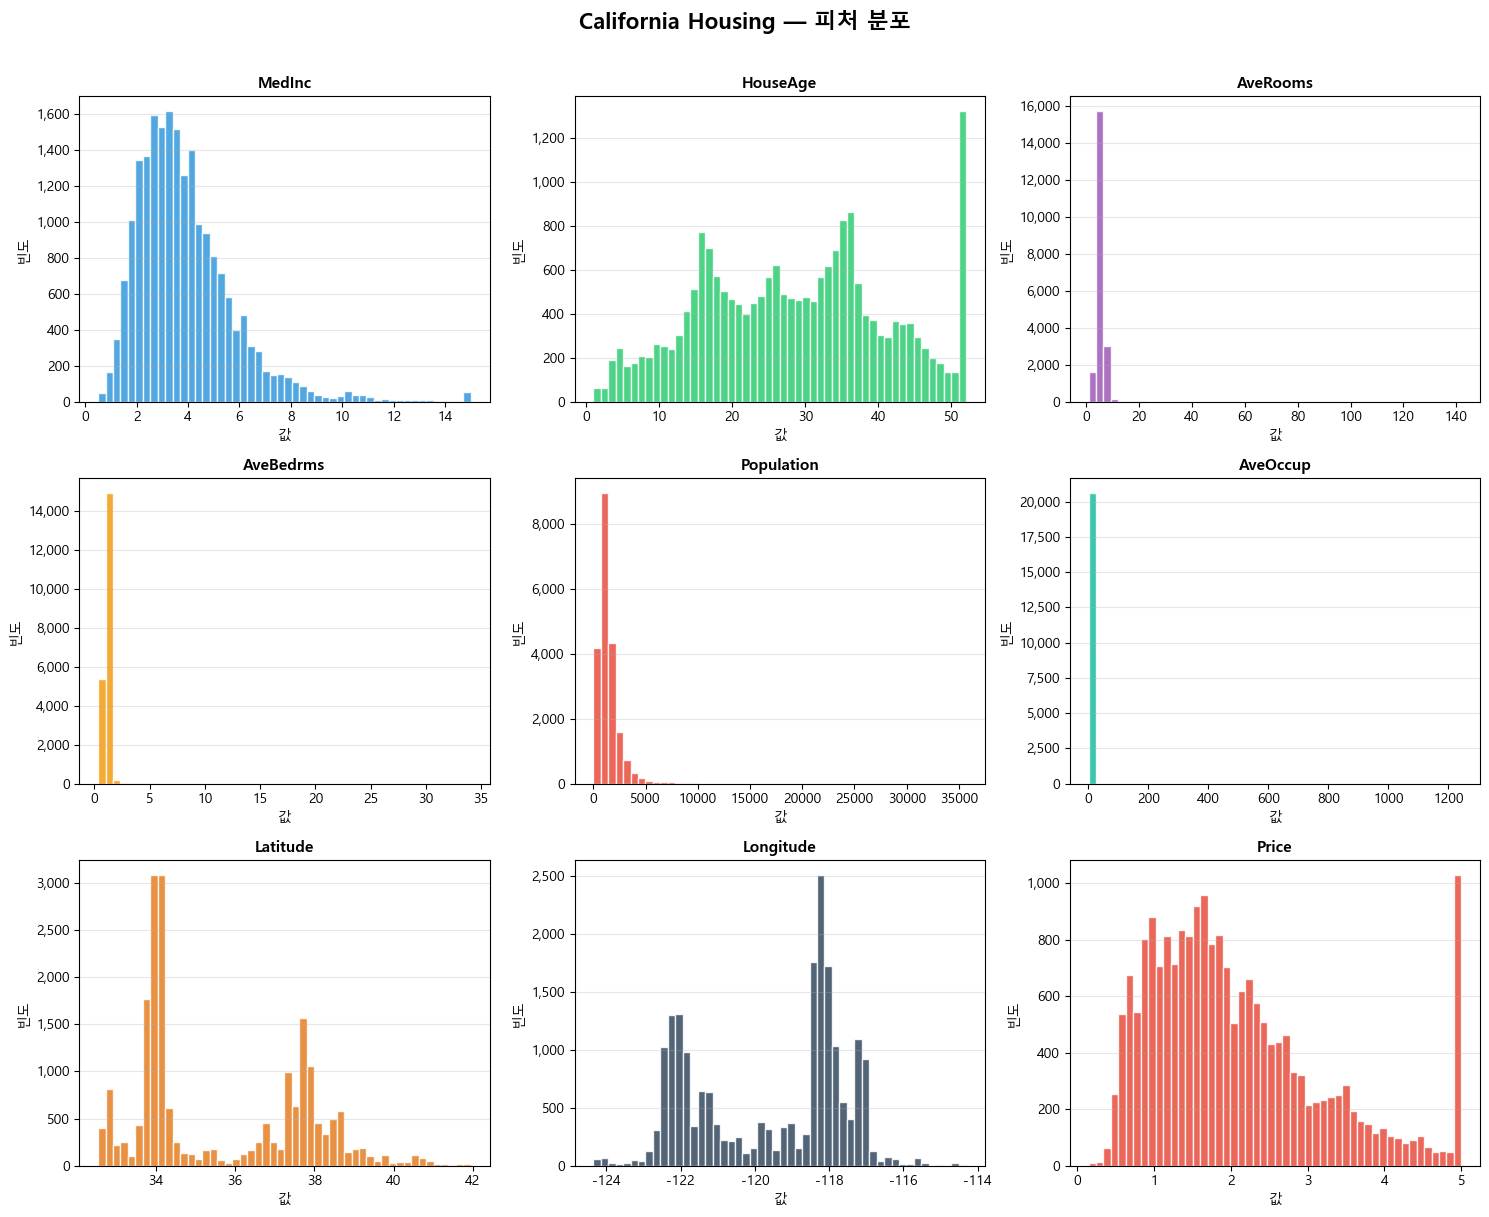

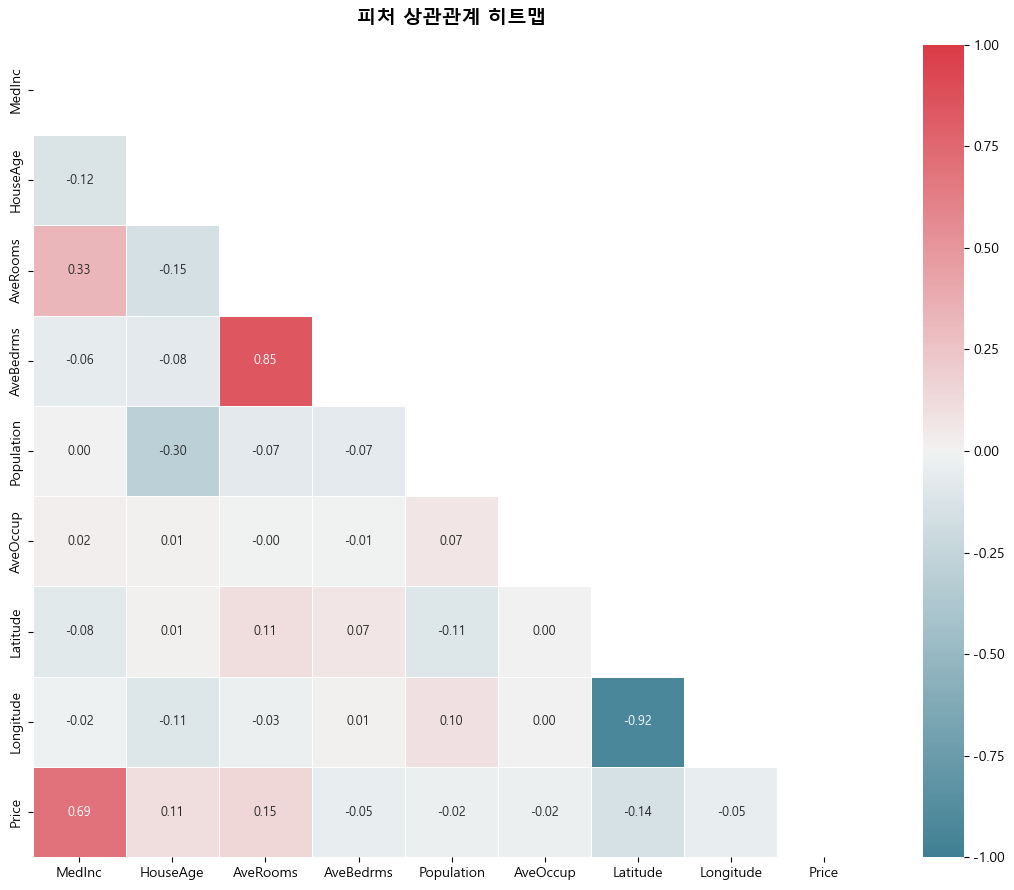

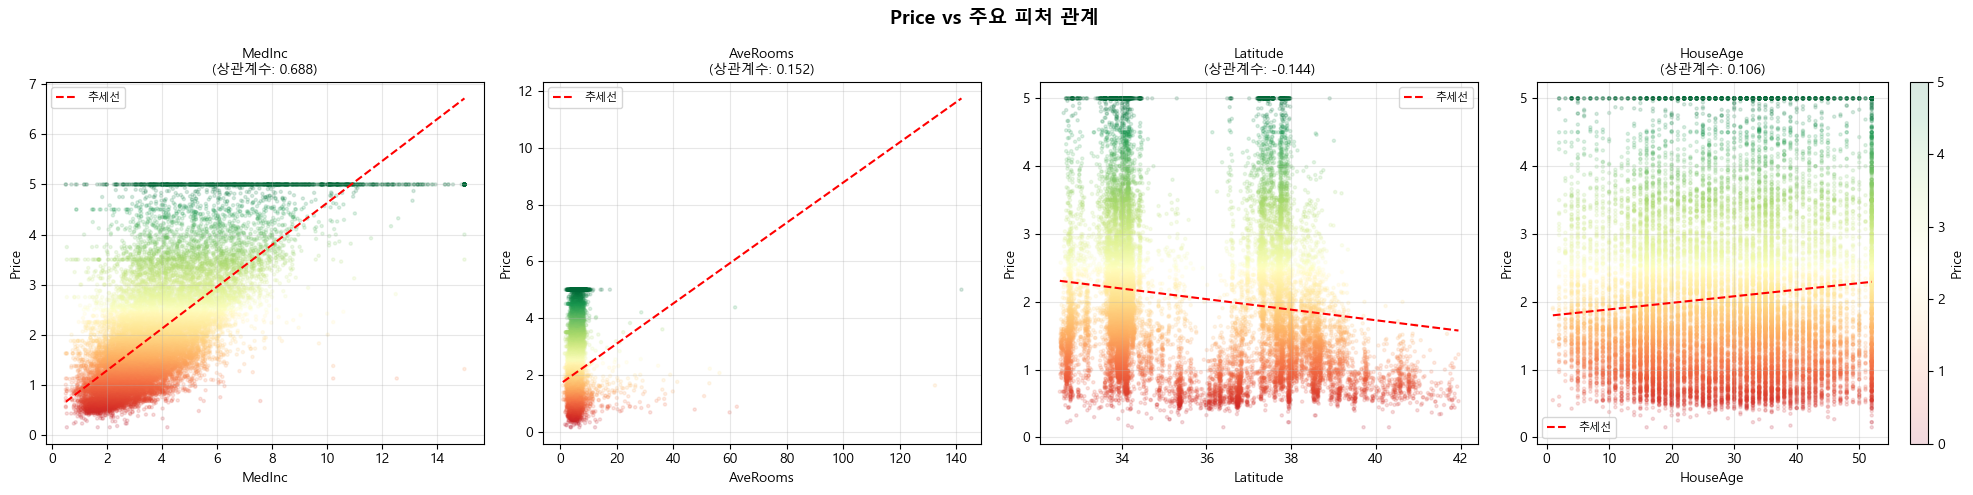

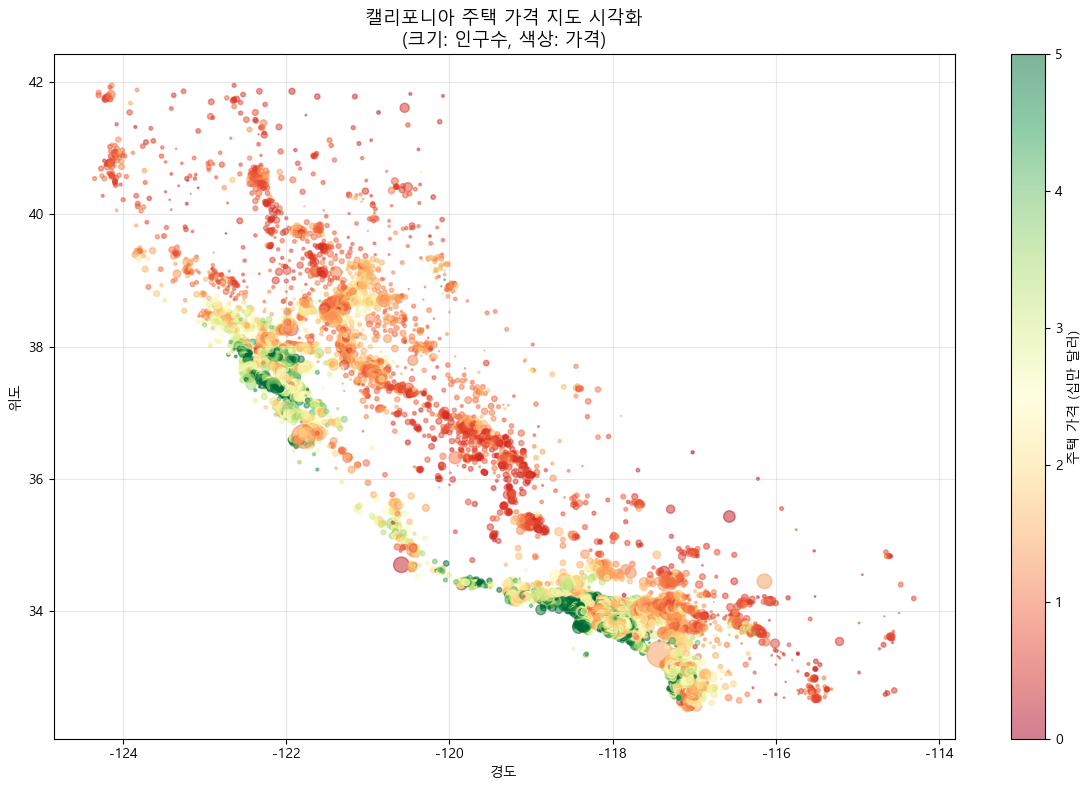


3. 데이터 전처리

이상치 제거  : 20,640 → 19,384행  (1256개 제거)
파생 피처    : RoomsPerPerson, BedroomsPerRoom, IncomeDensity, HouseAgeIncome
로그 변환    : ['Population', 'AveRooms', 'AveBedrms', 'AveOccup']

Train / Test : 15,507  /  3,877
Scaler       : RobustScaler 완료

4. 머신러닝 모델 비교 (5-Fold CV)

모델                        CV RMSE       ±     CV MAE    CV R²
--------------------------------------------------------------
  LinearRegression         0.6414  0.0107     0.4639   0.6916
  Ridge                    0.6414  0.0107     0.4639   0.6916
  Lasso                    0.6522  0.0107     0.4697   0.6811
  ElasticNet               0.6514  0.0106     0.4695   0.6819
  DecisionTree             0.6232  0.0136     0.3968   0.7088
  RandomForest             0.4903  0.0145     0.3152   0.8198
  ExtraTrees               0.5245  0.0104     0.3507   0.7938
  GradientBoosting         0.5237  0.0098     0.3600   0.7944
  SVR                      0.5597  0.0100     0.3803   0.7652

상위 3 모델: ['RandomForest', 'Gradient

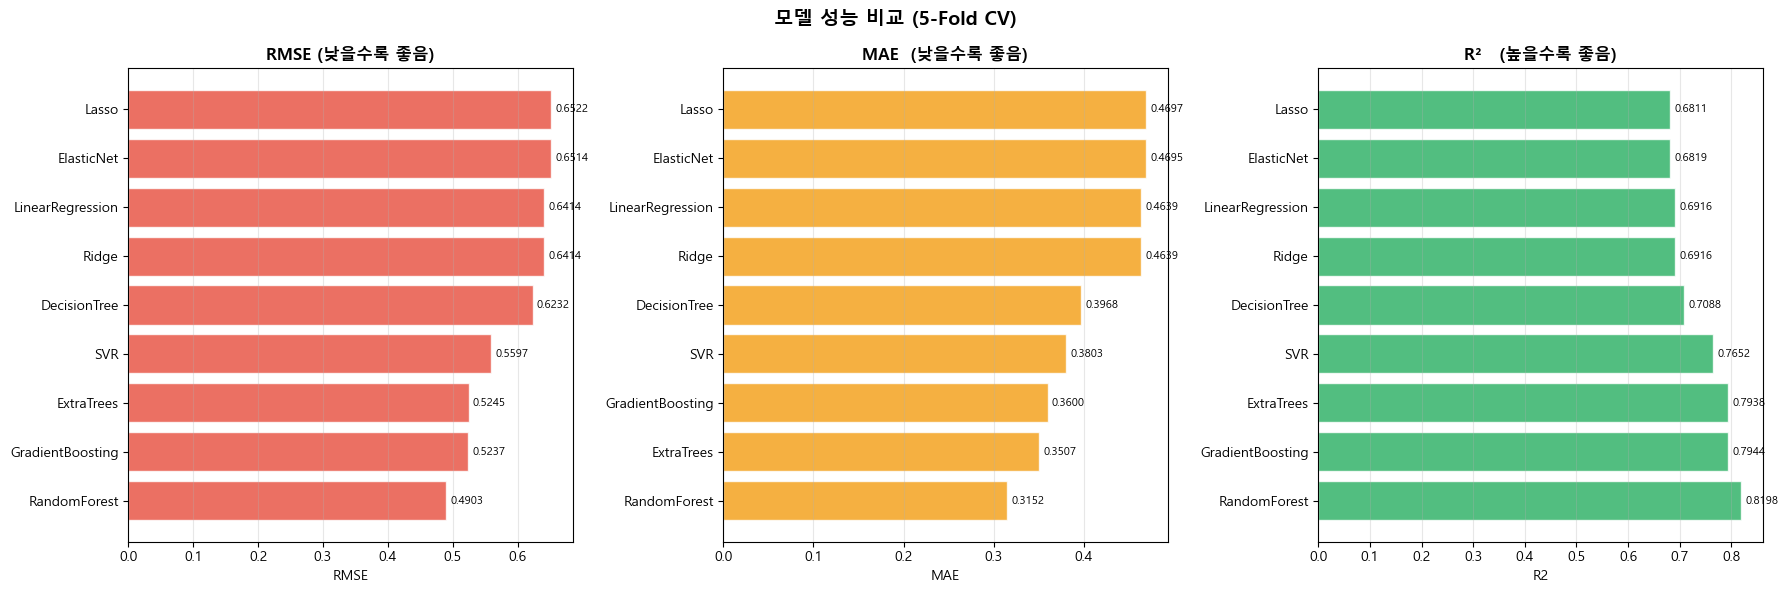


5. 테스트셋 평가 (상위 3 모델)

모델                         RMSE      MAE       R²
--------------------------------------------------
  RandomForest           0.4680   0.3027   0.8376
  GradientBoosting       0.5154   0.3568   0.8030
  ExtraTrees             0.5046   0.3352   0.8112

테스트셋 최고 모델: RandomForest


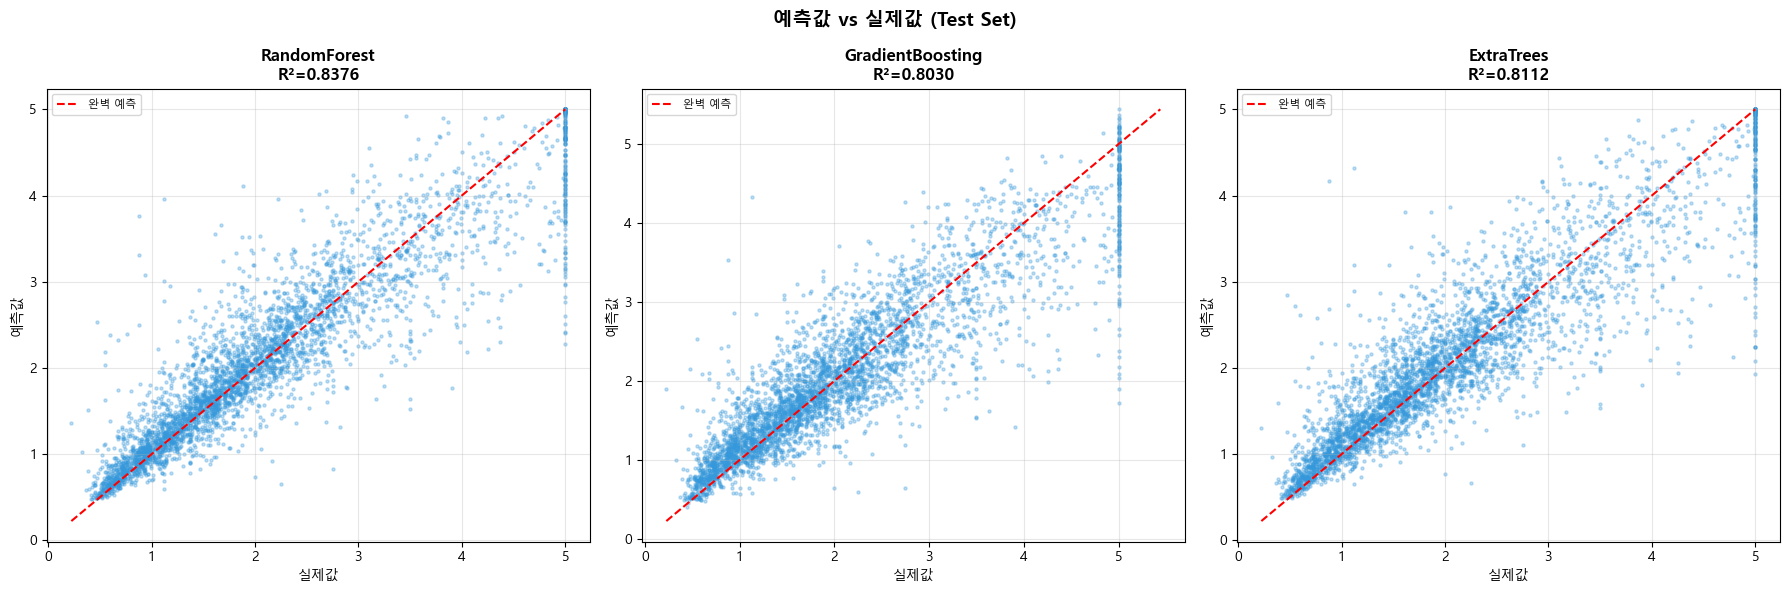

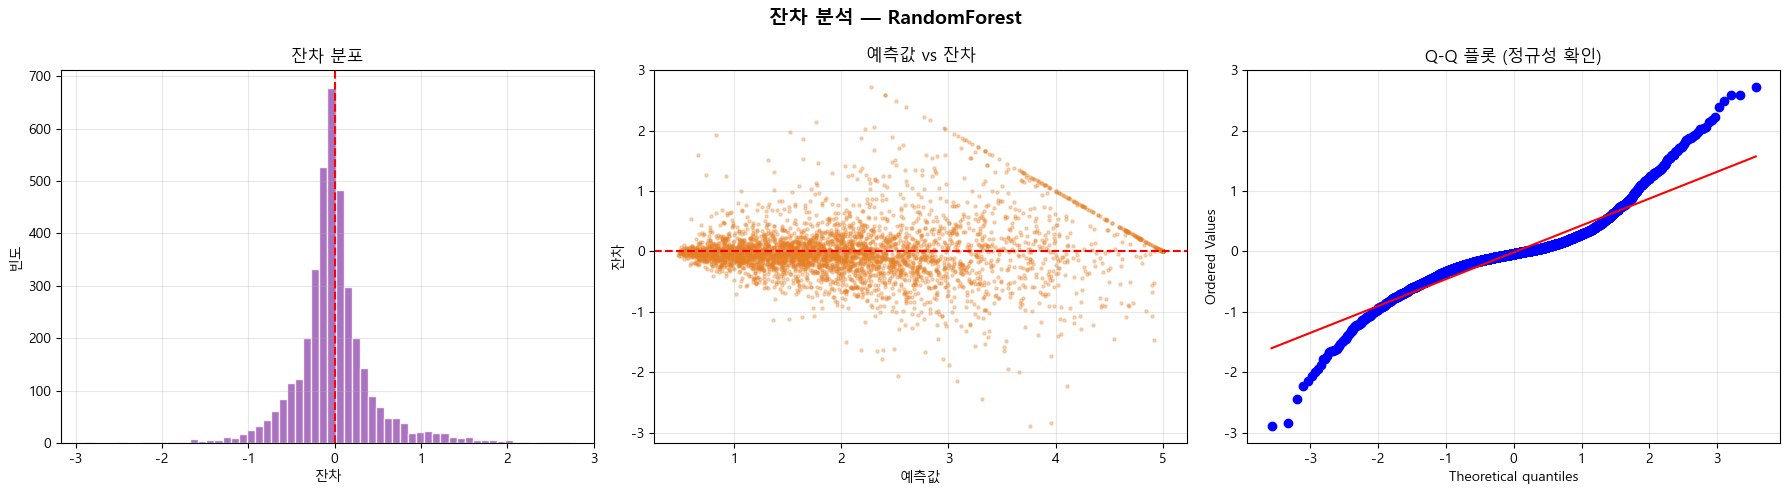


6. 피처 중요도 분석

[RandomForest] 피처 중요도 (Gini)
  IncomeDensity          0.6031  ████████████████████████████████████████████████
  Longitude              0.1000  ████████
  Latitude               0.0942  ███████
  HouseAgeIncome         0.0360  ██
  AveOccup               0.0247  █
  MedInc                 0.0221  █
  RoomsPerPerson         0.0221  █
  AveBedrms              0.0219  █
  Population             0.0218  █
  BedroomsPerRoom        0.0198  █
  AveRooms               0.0177  █
  HouseAge               0.0166  █


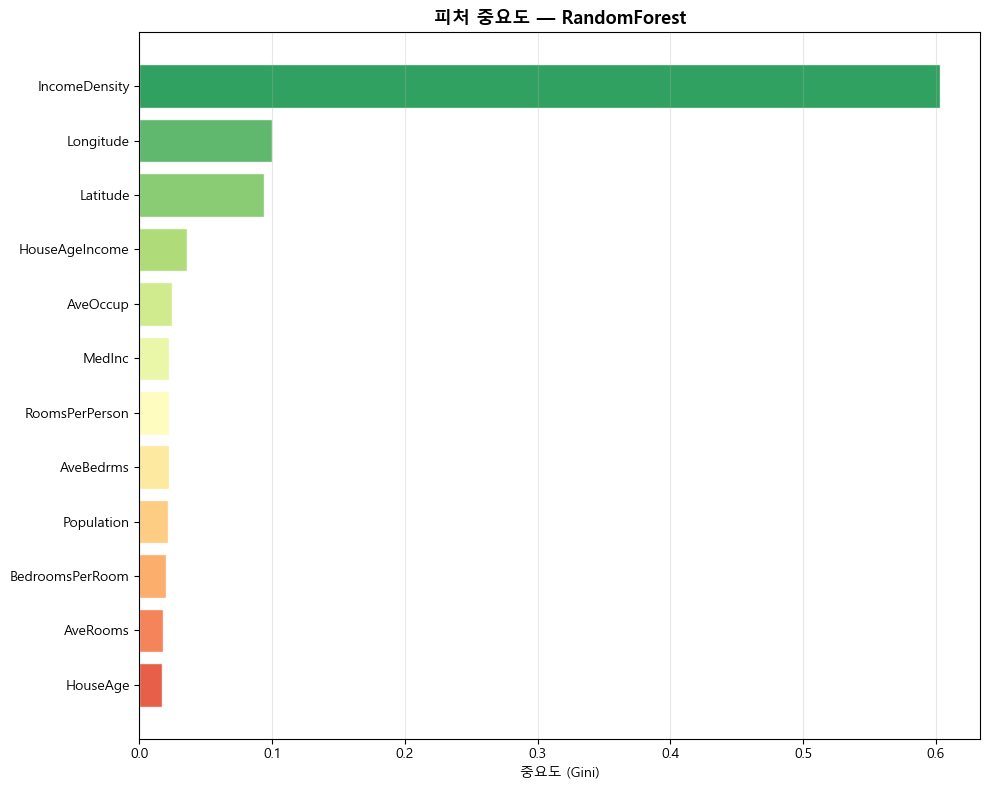


7. 하이퍼파라미터 튜닝

[GridSearchCV] RandomForest
  최적 파라미터 : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
  CV  RMSE      : 0.5290
  Test RMSE     : 0.5016
  Test R²       : 0.8135

[RandomizedSearchCV] GradientBoosting
  최적 파라미터 : {'learning_rate': 0.0849080237694725, 'max_depth': 7, 'max_features': 0.5917173949330818, 'min_samples_split': 9, 'n_estimators': 288, 'subsample': 0.879055047383946}
  CV  RMSE      : 0.4582
  Test RMSE     : 0.4275
  Test R²       : 0.8645


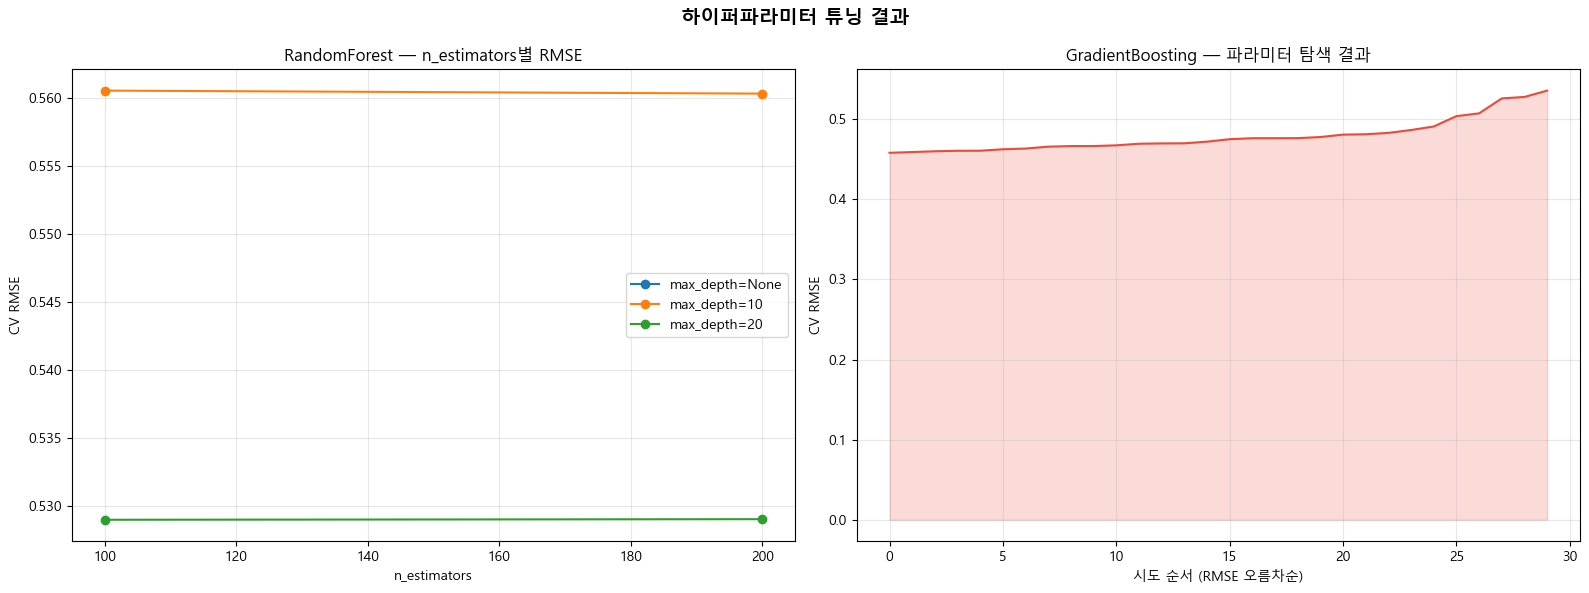


8. 최종 결과 요약

모델                                                RMSE       R²
----------------------------------------------------------------
  GradientBoosting (RandomSearch)               0.4275   0.8645
  RandomForest (기본)                             0.4680   0.8376
  RandomForest (GridSearch)                     0.5016   0.8135
  ExtraTrees (기본)                               0.5046   0.8112
  GradientBoosting (기본)                         0.5154   0.8030

🏆 최종 챔피언 : GradientBoosting (RandomSearch)
   Test RMSE   : 0.4275  (약 $42,755 오차)
   Test R²     : 0.8645

✅ 전체 분석 완료!


In [2]:
# =============================================================================
# 🏠 California Housing Price Analysis
# 분석 / 시각화 / 전처리 / 머신러닝 / 하이퍼파라미터 튜닝
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
from scipy.stats import randint, uniform

import platform
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# =============================================================================
# 1. 데이터 로드
# =============================================================================
print("=" * 70)
print("1. 데이터 로드")
print("=" * 70)

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df.rename(columns={"MedHouseVal": "Price"}, inplace=True)

feature_desc = {
    "MedInc":     "중위 소득 (만 달러)",
    "HouseAge":   "주택 연령 (년)",
    "AveRooms":   "평균 방 수",
    "AveBedrms":  "평균 침실 수",
    "Population": "블록 인구 수",
    "AveOccup":   "평균 거주자 수",
    "Latitude":   "위도",
    "Longitude":  "경도",
    "Price":      "주택 가격 (십만 달러) ← 타겟",
}

print("\n[컬럼 설명]")
for col, desc in feature_desc.items():
    print(f"  {col:<12} : {desc}")

print(f"\n데이터 shape : {df.shape}")

# =============================================================================
# 2. 탐색적 데이터 분석 (EDA)
# =============================================================================
print("\n" + "=" * 70)
print("2. 탐색적 데이터 분석 (EDA)")
print("=" * 70)

print("\n[기초 통계량]")
print(df.describe().round(3).to_string())

print("\n[결측치 확인]")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "  결측치 없음 ✅")

print("\n[왜도 / 첨도]")
print(pd.DataFrame({
    "skewness": df.skew().round(3),
    "kurtosis": df.kurtosis().round(3),
}))

print("\n[이상치 탐지 (IQR 1.5× 기준)]")
for col in df.columns:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:<12}: {n_out:5d}개 ({n_out / len(df) * 100:.1f}%)")

print("\n[타겟(Price) 상관 Top 5]")
print(df.corr()["Price"].drop("Price").abs().sort_values(ascending=False).head())

# ── 시각화 1: 피처 분포 히스토그램 ──────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("California Housing — 피처 분포", fontsize=16, fontweight="bold", y=1.01)

colors = ["#3498DB","#2ECC71","#9B59B6","#F39C12","#E74C3C",
          "#1ABC9C","#E67E22","#34495E","#E74C3C"]
for ax, col, clr in zip(axes.flat, df.columns, colors):
    ax.hist(df[col], bins=50, color=clr, edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("값")
    ax.set_ylabel("빈도")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ── 시각화 2: 상관관계 히트맵 ────────────────────────────────────────────
corr = df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt=".2f", linewidths=0.5,
            annot_kws={"size": 9}, ax=ax)
ax.set_title("피처 상관관계 히트맵", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# ── 시각화 3: 타겟 vs 주요 피처 산점도 ──────────────────────────────────
top_features = corr["Price"].drop("Price").abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Price vs 주요 피처 관계", fontsize=14, fontweight="bold")

for ax, feat in zip(axes, top_features):
    sc = ax.scatter(df[feat], df["Price"], alpha=0.15, s=5,
                    c=df["Price"], cmap="RdYlGn", vmin=0, vmax=5)
    m, b = np.polyfit(df[feat], df["Price"], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, "r--", linewidth=1.5, label="추세선")
    corr_val = df[[feat, "Price"]].corr().iloc[0, 1]
    ax.set_title(f"{feat}\n(상관계수: {corr_val:.3f})", fontsize=10)
    ax.set_xlabel(feat)
    ax.set_ylabel("Price")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.colorbar(sc, ax=axes[-1], label="Price")
plt.tight_layout()
plt.show()

# ── 시각화 4: 지도 시각화 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    df["Longitude"], df["Latitude"],
    c=df["Price"], cmap="RdYlGn",
    s=df["Population"] / 100, alpha=0.5, vmin=0, vmax=5
)
plt.colorbar(sc, ax=ax, label="주택 가격 (십만 달러)")
ax.set_title("캘리포니아 주택 가격 지도 시각화\n(크기: 인구수, 색상: 가격)", fontsize=13)
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. 데이터 전처리
# =============================================================================
print("\n" + "=" * 70)
print("3. 데이터 전처리")
print("=" * 70)

df_clean = df.copy()

# ── 극단 이상치 제거 (IQR 3.0×) ─────────────────────────────────────────
iqr_cols = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
before = len(df_clean)
for col in iqr_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df_clean = df_clean[
        (df_clean[col] >= Q1 - 3.0 * IQR) &
        (df_clean[col] <= Q3 + 3.0 * IQR)
    ]
print(f"\n이상치 제거  : {before:,} → {len(df_clean):,}행  ({before - len(df_clean)}개 제거)")

# ── 파생 피처 추가 ───────────────────────────────────────────────────────
df_clean["RoomsPerPerson"]  = df_clean["AveRooms"]  / df_clean["AveOccup"]
df_clean["BedroomsPerRoom"] = df_clean["AveBedrms"] / df_clean["AveRooms"]
df_clean["IncomeDensity"]   = df_clean["MedInc"]    / df_clean["AveOccup"]
df_clean["HouseAgeIncome"]  = df_clean["HouseAge"]  * df_clean["MedInc"]
print("파생 피처    : RoomsPerPerson, BedroomsPerRoom, IncomeDensity, HouseAgeIncome")

# ── 로그 변환 (왜도 큰 컬럼) ─────────────────────────────────────────────
log_cols = ["Population", "AveRooms", "AveBedrms", "AveOccup"]
for col in log_cols:
    df_clean[col] = np.log1p(df_clean[col])
print(f"로그 변환    : {log_cols}")

# ── Train / Test Split ───────────────────────────────────────────────────
X = df_clean.drop(columns=["Price"])
y = df_clean["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\nTrain / Test : {X_train.shape[0]:,}  /  {X_test.shape[0]:,}")

# ── 스케일링 (선형·SVM 전용) ─────────────────────────────────────────────
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Scaler       : RobustScaler 완료")

# =============================================================================
# 4. 머신러닝 모델 비교 (5-Fold CV)
# =============================================================================
print("\n" + "=" * 70)
print("4. 머신러닝 모델 비교 (5-Fold CV)")
print("=" * 70)

SCALED_MODELS = {"LinearRegression", "Ridge", "Lasso", "ElasticNet", "SVR"}

models = {
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(alpha=1.0),
    "Lasso":            Lasso(alpha=0.01),
    "ElasticNet":       ElasticNet(alpha=0.01, l1_ratio=0.5),
    "DecisionTree":     DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    "RandomForest":     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees":       ExtraTreesRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "SVR":              SVR(kernel="rbf", C=1.0, epsilon=0.1),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print(f"\n{'모델':<22} {'CV RMSE':>10} {'±':>7} {'CV MAE':>10} {'CV R²':>8}")
print("-" * 62)

for name, model in models.items():
    X_use = X_train_sc if name in SCALED_MODELS else X_train.values

    rmse = np.sqrt(-cross_val_score(
        model, X_use, y_train, cv=kf,
        scoring="neg_mean_squared_error", n_jobs=-1))
    mae = -cross_val_score(
        model, X_use, y_train, cv=kf,
        scoring="neg_mean_absolute_error", n_jobs=-1)
    r2 = cross_val_score(
        model, X_use, y_train, cv=kf, scoring="r2", n_jobs=-1)

    cv_results[name] = {
        "rmse": rmse.mean(), "rmse_std": rmse.std(),
        "mae": mae.mean(), "r2": r2.mean(),
    }
    print(f"  {name:<20} {rmse.mean():>10.4f} {rmse.std():>7.4f}"
          f" {mae.mean():>10.4f} {r2.mean():>8.4f}")

cv_df = pd.DataFrame(cv_results).T.sort_values("rmse")
print(f"\n상위 3 모델: {cv_df.head(3).index.tolist()}")

# ── 시각화 5: 모델 성능 비교 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("모델 성능 비교 (5-Fold CV)", fontsize=14, fontweight="bold")

for ax, (metric, color, title) in zip(axes, [
    ("rmse", "#E74C3C", "RMSE (낮을수록 좋음)"),
    ("mae",  "#F39C12", "MAE  (낮을수록 좋음)"),
    ("r2",   "#27AE60", "R²   (높을수록 좋음)"),
]):
    vals = cv_df[metric].sort_values(ascending=(metric != "r2"))
    bars = ax.barh(vals.index, vals.values, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(metric.upper())
    for bar, val in zip(bars, vals.values):
        ax.text(val + vals.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# 5. 테스트셋 평가 (상위 3 모델)
# =============================================================================
print("\n" + "=" * 70)
print("5. 테스트셋 평가 (상위 3 모델)")
print("=" * 70)

top3 = cv_df.head(3).index.tolist()
test_results = {}

for name in top3:
    model = models[name]
    X_tr = X_train_sc if name in SCALED_MODELS else X_train.values
    X_te = X_test_sc  if name in SCALED_MODELS else X_test.values
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    test_results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE":  mean_absolute_error(y_test, y_pred),
        "R2":   r2_score(y_test, y_pred),
        "pred": y_pred,
    }

print(f"\n{'모델':<22} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 50)
for name, m in test_results.items():
    print(f"  {name:<20} {m['RMSE']:>8.4f} {m['MAE']:>8.4f} {m['R2']:>8.4f}")

best_name = min(test_results, key=lambda k: test_results[k]["RMSE"])
print(f"\n테스트셋 최고 모델: {best_name}")

# ── 시각화 6: 예측값 vs 실제값 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("예측값 vs 실제값 (Test Set)", fontsize=14, fontweight="bold")

for ax, name in zip(axes, top3):
    y_pred = test_results[name]["pred"]
    ax.scatter(y_test, y_pred, alpha=0.3, s=5, color="#3498DB")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="완벽 예측")
    ax.set_xlabel("실제값")
    ax.set_ylabel("예측값")
    ax.set_title(f"{name}\nR²={test_results[name]['R2']:.4f}", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── 시각화 7: 잔차 분석 ──────────────────────────────────────────────────
y_pred_best = test_results[best_name]["pred"]
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"잔차 분석 — {best_name}", fontsize=14, fontweight="bold")

axes[0].hist(residuals, bins=60, color="#9B59B6", edgecolor="white", alpha=0.85)
axes[0].set_title("잔차 분포")
axes[0].set_xlabel("잔차")
axes[0].set_ylabel("빈도")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=5, color="#E67E22")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("예측값 vs 잔차")
axes[1].set_xlabel("예측값")
axes[1].set_ylabel("잔차")
axes[1].grid(alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q 플롯 (정규성 확인)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. 피처 중요도 분석
# =============================================================================
print("\n" + "=" * 70)
print("6. 피처 중요도 분석")
print("=" * 70)

tree_candidates = [m for m in top3
                   if m in {"RandomForest", "ExtraTrees", "GradientBoosting", "DecisionTree"}]
fi_name  = tree_candidates[0] if tree_candidates else "RandomForest"
fi_model = models[fi_name]
fi_model.fit(X_train.values, y_train)

fi_df = pd.DataFrame({
    "feature":    X_train.columns.tolist(),
    "importance": fi_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"\n[{fi_name}] 피처 중요도 (Gini)")
for _, row in fi_df.iterrows():
    bar = "█" * int(row["importance"] * 80)
    print(f"  {row['feature']:<22} {row['importance']:.4f}  {bar}")

# ── 시각화 8: 피처 중요도 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(fi_df)))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1],
        color=colors_fi, edgecolor="white", alpha=0.9)
ax.set_title(f"피처 중요도 — {fi_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("중요도 (Gini)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# 7. 하이퍼파라미터 튜닝
# =============================================================================
print("\n" + "=" * 70)
print("7. 하이퍼파라미터 튜닝")
print("=" * 70)

# ── GridSearchCV — RandomForest ───────────────────────────────────────────
print("\n[GridSearchCV] RandomForest")

rf_param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features":      ["sqrt", "log2"],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=0,
)
rf_grid.fit(X_train.values, y_train)
y_pred_rf = rf_grid.best_estimator_.predict(X_test.values)

print(f"  최적 파라미터 : {rf_grid.best_params_}")
print(f"  CV  RMSE      : {-rf_grid.best_score_:.4f}")
print(f"  Test RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")
print(f"  Test R²       : {r2_score(y_test, y_pred_rf):.4f}")

# ── RandomizedSearchCV — GradientBoosting ────────────────────────────────
print("\n[RandomizedSearchCV] GradientBoosting")

gb_param_dist = {
    "n_estimators":      randint(100, 400),
    "learning_rate":     uniform(0.01, 0.2),
    "max_depth":         randint(3, 8),
    "min_samples_split": randint(2, 20),
    "subsample":         uniform(0.7, 0.3),
    "max_features":      uniform(0.5, 0.5),
}

gb_rand = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=gb_param_dist,
    n_iter=30, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
gb_rand.fit(X_train.values, y_train)
y_pred_gb = gb_rand.best_estimator_.predict(X_test.values)

print(f"  최적 파라미터 : {gb_rand.best_params_}")
print(f"  CV  RMSE      : {-gb_rand.best_score_:.4f}")
print(f"  Test RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}")
print(f"  Test R²       : {r2_score(y_test, y_pred_gb):.4f}")

# ── 시각화 9: 튜닝 결과 ──────────────────────────────────────────────────
rf_cv_res = pd.DataFrame(rf_grid.cv_results_)
rf_cv_res["mean_rmse"] = -rf_cv_res["mean_test_score"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("하이퍼파라미터 튜닝 결과", fontsize=14, fontweight="bold")

for max_d in [None, 10, 20]:
    sub = (rf_cv_res[rf_cv_res["param_max_depth"] == max_d]
           .groupby("param_n_estimators")["mean_rmse"].min())
    axes[0].plot(sub.index, sub.values, marker="o", label=f"max_depth={max_d}")
axes[0].set_title("RandomForest — n_estimators별 RMSE")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("CV RMSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

gb_cv_res = pd.DataFrame(gb_rand.cv_results_)
gb_cv_res["mean_rmse"] = -gb_cv_res["mean_test_score"]
sorted_rmse = gb_cv_res["mean_rmse"].sort_values().values

axes[1].plot(range(len(sorted_rmse)), sorted_rmse, color="#E74C3C", linewidth=1.5)
axes[1].fill_between(range(len(sorted_rmse)), sorted_rmse, alpha=0.2, color="#E74C3C")
axes[1].set_title("GradientBoosting — 파라미터 탐색 결과")
axes[1].set_xlabel("시도 순서 (RMSE 오름차순)")
axes[1].set_ylabel("CV RMSE")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# 8. 최종 결과 요약
# =============================================================================
print("\n" + "=" * 70)
print("8. 최종 결과 요약")
print("=" * 70)

final = {}
for name, m in test_results.items():
    final[f"{name} (기본)"] = (m["RMSE"], r2_score(y_test, m["pred"]))
final["RandomForest (GridSearch)"]       = (np.sqrt(mean_squared_error(y_test, y_pred_rf)),
                                             r2_score(y_test, y_pred_rf))
final["GradientBoosting (RandomSearch)"] = (np.sqrt(mean_squared_error(y_test, y_pred_gb)),
                                             r2_score(y_test, y_pred_gb))

print(f"\n{'모델':<45} {'RMSE':>8} {'R²':>8}")
print("-" * 64)
for name, (rmse, r2) in sorted(final.items(), key=lambda x: x[1][0]):
    print(f"  {name:<43} {rmse:>8.4f} {r2:>8.4f}")

champion = min(final.items(), key=lambda x: x[1][0])
print(f"\n🏆 최종 챔피언 : {champion[0]}")
print(f"   Test RMSE   : {champion[1][0]:.4f}  (약 ${champion[1][0] * 100_000:,.0f} 오차)")
print(f"   Test R²     : {champion[1][1]:.4f}")

print("\n" + "=" * 70)
print("✅ 전체 분석 완료!")
print("=" * 70)

In [3]:
# end